# 실험 설계서: PCA 기반 차원 축소와 예측 모델 성능 상관관계 분석

## 1. 실험 개요 (Overview)
본 실험은 고차원 화학 성분 데이터($X$)가 관능 평가 점수($Y$)를 예측하는 데 있어, **차원 축소(PCA)가 모델 성능에 미치는 영향**을 분석하는 것을 목적으로 한다.
특히, **데이터 누수(Data Leakage)**를 엄격히 방지하기 위해 Test Set을 학습 과정(Scaling, PCA Fitting)에서 완전히 배제하며, 차원 수 변화에 따른 성능 추이를 통해 최적의 특징 추출(Feature Extraction) 차원을 도출한다.

## 2. 데이터셋 구성 (Dataset Configuration)
* **독립 변수 ($X$):** 맥주 화학 성분 데이터 (231차원)
* **종속 변수 ($Y$):** 전문 패널 관능 평가 점수 (50+ 차원)
* **메타 정보:** 맥주 스타일 (`tasting_category_fine`) - 층화 추출의 기준

## 3. 실험 절차 (Experimental Pipeline)

### Phase 1. 데이터 분할 (Data Splitting)
* **기법:** 층화 추출 (Stratified Split)
* **비율:** Training Set (80%) / Test Set (20%)
* **목적:** 데이터 불균형(Class Imbalance) 해소를 위해 각 맥주 스타일의 비율을 Train/Test 셋에 동일하게 유지함.
* **제약 사항:** 종속 변수($Y$)는 차원 축소 대상이 아니므로 원본 상태를 유지함.

### Phase 2. 전처리 및 정규화 (Preprocessing)
* **알고리즘:** Standard Scaling (Z-score normalization)
* **Data Leakage 방지 전략:**
    1.  `StandardScaler`는 오직 **Train Set**의 평균($\mu$)과 분산($\sigma^2$)으로만 학습(`fit`)한다.
    2.  **Test Set**은 Train Set에서 도출된 파라미터를 사용하여 변환(`transform`)만 수행한다.
    
### Phase 3. 주성분 분석 및 특징 추출 (PCA & Feature Extraction)
* **알고리즘:** Principal Component Analysis (SVD 기반)
* **학습:** 정규화된 **Train Set**을 이용하여 공분산 행렬의 고유벡터(Eigenvectors, 주성분 축)를 도출한다.
* **투영 (Projection):**
    * Train Set과 Test Set을 도출된 주성분 축으로 투영하여 새로운 좌표계로 변환한다.
    * 이때, Test Set은 Train Set이 정의한 축을 그대로 따른다.

### Phase 4. 차원별 성능 평가 루프 (Evaluation Loop)
다양한 차원($N$)에 대해 아래 과정을 반복 수행한다.
* **대상 차원 리스트:** `[231(Full), 200, 150, 100, 50, 30, 20, 10, 5, 1]`
* **Step 1 (Slicing):** 투영된 데이터에서 상위 $N$개의 주성분(Column)만 선택.
* **Step 2 (Modeling):**
    * **모델:** XGBoost Regressor (Multi-Output 지원)
    * **입력:** $N$차원으로 축소된 Train $X'$
    * **타겟:** 원본 Train $Y$
* **Step 3 (Validation):**
    * $N$차원으로 축소된 Test $X'$를 모델에 입력하여 $Y$ 예측.
    * 실제 Test $Y$와 비교하여 $R^2$ Score 산출.

## 4. 모델 아키텍처 (Model Architecture)
* **Regressor:** XGBoost (Extreme Gradient Boosting)
* **Hyperparameters:** `n_estimators=100`, `n_jobs=-1` (기본 설정)
* **Wrapper:** `MultiOutputRegressor` (다변량 회귀 문제 해결을 위함)

## 5. 평가지표 및 시각화 (Metrics & Visualization)
1.  **Scree Plot:** 주성분 개수에 따른 누적 설명 분산 비율(Cumulative Explained Variance Ratio) 시각화. (정보 보존량 확인)
2.  **Performance Plot:** 차원 수($x$) 대 모델 성능($R^2$, $y$) 그래프 시각화. (Elbow Point 및 최적 차원 탐색)

---
**※ 핵심 주의사항 (Key Constraints)**
> 본 실험의 모든 전처리(Scaling)와 특징 추출(PCA Fitting) 기준은 **오직 Training Data**로부터 유도되어야 하며, Test Data는 검증 단계 전까지 학습 파이프라인에 어떠한 통계적 영향도 주어서는 안 된다.

# 실험 코드 분석 보고서: PCA 차원 축소와 다변량 회귀 성능 상관관계

## 1. 코드의 의도 (Intention)
이 코드는 고차원의 화학 성분 데이터(231개 변수)가 관능 평가(맛, 향 등)를 예측하는 데 있어 **"과적합(Overfitting)을 피하고 핵심 정보만 남기는 최적의 차원 수"**가 무엇인지 찾기 위해 작성되었습니다.

특히, 데이터 분석 실험에서 범하기 쉬운 오류들을 방지하기 위해 다음 두 가지 핵심 철학이 반영되어 있습니다.
1.  **데이터 누수(Data Leakage) 원천 차단:** Scaling과 PCA의 기준(Fit)을 오직 학습 데이터(Train Set)에서만 잡고, 테스트 데이터(Test Set)는 그 기준에 따르도록 함.
2.  **수학적 제약 조건 준수:** 데이터 샘플 수(N)보다 특성 수(D)가 많을 때 발생하는 PCA 차원 오류를 방지하기 위해 `min(N, D)` 로직을 적용.

---

## 2. 말로 서술하는 실험 설계 (Verbal Design)

이 실험은 총 5단계의 파이프라인으로 구성됩니다.

### **[Step 1] 데이터 격리 및 층화 추출**
* 전체 데이터를 로드하여 $X$(화학)와 $Y$(관능)로 분리합니다.
* 이때, 맥주 스타일(예: Lager, Ale 등)의 비율이 한쪽으로 쏠리지 않도록 **층화 추출(Stratified Split)** 방식을 사용하여 Train(80%)과 Test(20%)로 나눕니다.

### **[Step 2] 스케일링 (Scaling)**
* PCA는 데이터의 단위(Scale)에 민감하므로 정규화를 수행합니다.
* **중요:** `Train` 데이터의 평균과 분산만 계산(`fit`)하고, `Test` 데이터는 이 기준을 가져와서 변환(`transform`)만 수행하여 테스트 데이터의 정보가 학습 과정에 새어 들어가는 것을 막습니다.

### **[Step 3] PCA 주성분 추출 (Full Decomposition)**
* 차원을 바로 줄이지 않고, 수학적으로 계산 가능한 **최대 차원(Max Components)**까지 모든 주성분 축을 먼저 찾습니다.
* 이때 최대 차원은 데이터의 개수(행)와 변수의 개수(열) 중 **더 작은 값**으로 자동 설정하여 에러를 방지합니다.
* 찾아낸 축을 기준으로 Train과 Test 데이터를 모두 투영(Projection)해 둡니다.

### **[Step 4] 차원별 성능 검증 루프 (Validation Loop)**
* `[200, 150, ..., 5, 1]` 등 다양한 차원 리스트를 순회합니다.
* 미리 계산해 둔 데이터에서 앞에서부터 $N$개의 컬럼만 잘라냅니다 (**Slicing**).
* **XGBoost** 모델(여러 개의 Y를 동시에 맞추는 `MultiOutputRegressor`)을 학습시키고, Test 데이터에 대한 예측 정확도($R^2$)를 기록합니다.

### **[Step 5] 시각화 (Visualization)**
* **Scree Plot:** 주성분이 늘어날수록 정보량(분산)이 얼마나 보존되는지 확인합니다.
* **Performance Plot:** 차원을 줄였을 때 모델 성능이 어떻게 변하는지(Elbow Point)를 시각적으로 확인합니다.

---

## 3. 코드-설계 매칭 (Code Mapping)

위 설계 내용이 실제 코드의 어느 부분에 구현되어 있는지 1:1로 매칭한 내역입니다.

| 설계 단계 | 핵심 로직 설명 | 코드 매칭 (Line Reference) |
| :--- | :--- | :--- |
| **층화 추출** | 스타일 비율 유지하며 8:2 분할 | `train_test_split(..., stratify=styles)` |
| **누수 방지** | Train만 보고 기준 잡기(Fit) | `scaler.fit_transform(X_train)` <br> `scaler.transform(X_test)` |
| **PCA 오류 방지** | 행/열 중 작은 값으로 차원 한계 설정 | `max_possible_dim = min(X_train_scaled.shape[0], ...)` <br> `pca_full = PCA(n_components=max_possible_dim)` |
| **데이터 투영** | 찾아낸 축으로 좌표 변환 | `X_train_pca_full = pca_full.fit_transform(...)` |
| **차원 슬라이싱** | N개 차원만 잘라내서 실험 | `X_train_reduced = X_train_pca_full[:, :n]` |
| **모델링** | 다변량 회귀(Y가 여러 개) 수행 | `MultiOutputRegressor(XGBRegressor(...))` |
| **평가** | 테스트 셋으로 성능 검증 | `score = r2_score(Y_test, y_pred)` |
| **리스트 필터링** | 불가능한 차원 요청 제거 로직 | `n_components_list = [n for n in ... if n <= max_possible_dim]` |

---

## 4. 결론 및 요약
이 코드는 **"데이터의 양(Sample Size)이 변수의 개수(Feature Size)보다 적은 희소 데이터 상황"**을 정확하게 인지하고 처리하도록 설계되었습니다. 단순한 모델 학습을 넘어, **데이터 전처리 과정에서의 엄격한 격리(Isolation)**와 **수학적 타당성**을 확보한 실험 코드입니다.

👉 [Step 1] 데이터 로드 및 층화 추출 진행 중...
   - Train 개수: 200, Test 개수: 50

👉 [Step 2] 스케일링 (Train 데이터 기준)...

👉 [Step 3] PCA 전체 차원 학습...
   - 최대 생성 가능 주성분 개수: 200개

👉 [Step 4] 차원별 모델 성능 실험 시작 (XGBoost)...
   [Dims: 200] R2 Score: -0.4389
   [Dims: 150] R2 Score: -0.2944
   [Dims: 100] R2 Score: 0.0102
   [Dims:  50] R2 Score: 0.0131
   [Dims:  30] R2 Score: 0.0010
   [Dims:  20] R2 Score: -0.0179
   [Dims:  10] R2 Score: -0.0394
   [Dims:   5] R2 Score: -0.0813
   [Dims:   1] R2 Score: -0.6886

👉 [Step 5] 결과 그래프 그리기...


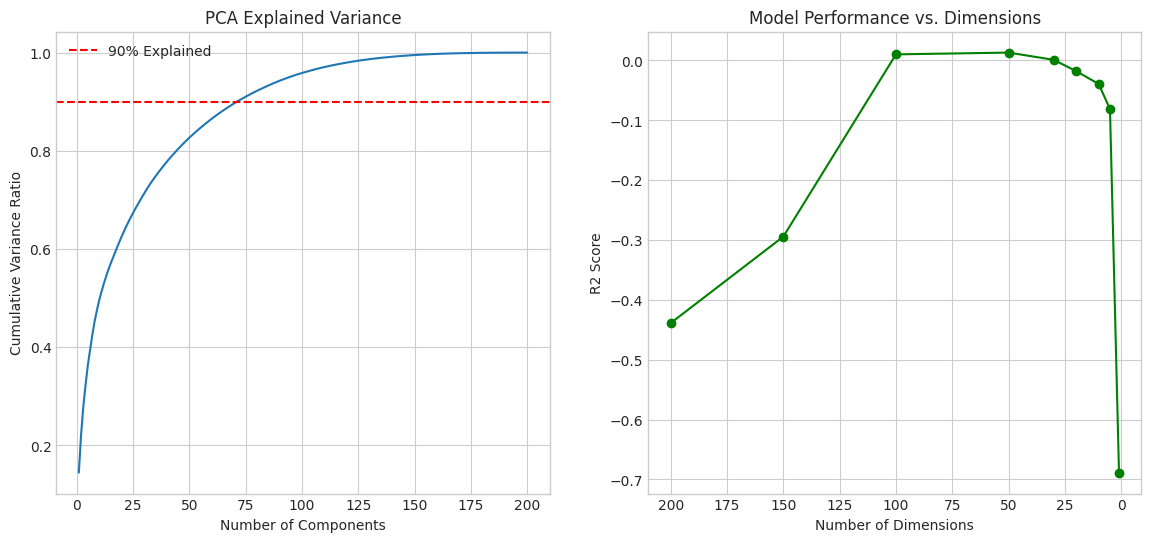


💾 실험 완료! 그래프 저장: /home/a202192020/맥주데이터실험/ver4/output/pca_experiment_result_fixed.png


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# 시각화 설정
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

# =========================================================
# 👉 [Step 1] 데이터 준비 및 층화 추출
# =========================================================
print("👉 [Step 1] 데이터 로드 및 층화 추출 진행 중...")

DATA_DIR = r"/home/a202192020/맥주데이터실험/data"
XLSX_NAME = "Supplemental Files and Figure source files.xlsx"
path = os.path.join(DATA_DIR, XLSX_NAME)

xls = pd.ExcelFile(path)
df_chem = xls.parse("Supplementary File S1").set_index('beer_id')
df_panel = xls.parse("Supplementary File S4").set_index('beer_id')
df_merged = df_chem.join(df_panel, how='inner', lsuffix='_chem', rsuffix='_panel')

style_col = 'tasting_category_fine'
if style_col not in df_merged.columns:
    style_col = [c for c in df_merged.columns if 'category' in c][0]

try:
    x_start = df_merged.columns.get_loc("acetaldehyde")
    x_end = df_merged.columns.get_loc("sulfur_sum")
    X = df_merged.iloc[:, x_start : x_end+1].fillna(0)
except KeyError:
    numeric_cols = df_merged.select_dtypes(include=[np.number]).columns
    X = df_merged[numeric_cols[:231]].fillna(0)

Y_cols = [c for c in df_merged.columns if c not in X.columns and c != style_col and df_merged[c].dtype != 'object']
Y = df_merged[Y_cols].fillna(0)
styles = df_merged[style_col]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=styles
)
print(f"   - Train 개수: {len(X_train)}, Test 개수: {len(X_test)}")

# =========================================================
# 👉 [Step 2] 스케일링
# =========================================================
print("\n👉 [Step 2] 스케일링 (Train 데이터 기준)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 👉 [Step 3] PCA 전체 차원 학습 (수정됨!)
# =========================================================
print("\n👉 [Step 3] PCA 전체 차원 학습...")

# [수정 핵심] 데이터 개수(200)보다 더 많은 차원(231)은 못 만듦. 둘 중 작은 값 사용.
max_possible_dim = min(X_train_scaled.shape[0], X_train_scaled.shape[1])
print(f"   - 최대 생성 가능 주성분 개수: {max_possible_dim}개")

pca_full = PCA(n_components=max_possible_dim)
X_train_pca_full = pca_full.fit_transform(X_train_scaled)
X_test_pca_full = pca_full.transform(X_test_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# =========================================================
# 👉 [Step 4] 차원 축소 반복 실험 (수정됨!)
# =========================================================
print("\n👉 [Step 4] 차원별 모델 성능 실험 시작 (XGBoost)...")

# [수정 핵심] 실험 리스트에서 불가능한 숫자(231) 제거하고 max_possible_dim 추가
# 예: [200, 150, 100, 50, ...]
n_components_list = [200, 150, 100, 50, 30, 20, 10, 5, 1]
# 만약 데이터가 너무 적어서 200개도 안 되면 필터링
n_components_list = [n for n in n_components_list if n <= max_possible_dim]

# 맨 앞에 '가능한 최대 차원'을 추가 (Baseline 역할)
if max_possible_dim not in n_components_list:
    n_components_list.insert(0, max_possible_dim)

results_r2 = []
model = MultiOutputRegressor(XGBRegressor(n_estimators=100, n_jobs=-1, random_state=42))

for n in n_components_list:
    X_train_reduced = X_train_pca_full[:, :n]
    X_test_reduced = X_test_pca_full[:, :n]
    
    model.fit(X_train_reduced, Y_train)
    y_pred = model.predict(X_test_reduced)
    score = r2_score(Y_test, y_pred)
    
    results_r2.append(score)
    print(f"   [Dims: {n:3d}] R2 Score: {score:.4f}")

# =========================================================
# 👉 [Step 5] 결과 시각화
# =========================================================
print("\n👉 [Step 5] 결과 그래프 그리기...")
plt.figure(figsize=(14, 6))

# Scree Plot
plt.subplot(1, 2, 1)
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Explained')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Ratio')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(True)

# Performance Plot
plt.subplot(1, 2, 2)
plt.plot(n_components_list, results_r2, marker='o', color='green')
plt.xlabel('Number of Dimensions')
plt.ylabel('R2 Score')
plt.title('Model Performance vs. Dimensions')
plt.gca().invert_xaxis()
plt.grid(True)

output_dir = r"/home/a202192020/맥주데이터실험/ver4/output"
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, "pca_experiment_result_fixed.png")
plt.savefig(save_path, dpi=300)
plt.show()

print(f"\n💾 실험 완료! 그래프 저장: {save_path}")

In [4]:
# =========================================================
# 🔍 [검증] 층화 추출(Stratified Split) 결과 확인 코드
# =========================================================

# 1. Train과 Test에 배정된 스타일 개수 세기
# (X_train, X_test의 인덱스를 이용해 styles에서 찾아옵니다)
train_counts = styles.loc[X_train.index].value_counts().sort_index()
test_counts = styles.loc[X_test.index].value_counts().sort_index()
total_counts = styles.value_counts().sort_index()

# 2. 하나의 데이터프레임으로 합치기
split_report = pd.DataFrame({
    'Total': total_counts,
    'Train (80%)': train_counts,
    'Test (20%)': test_counts
})

# 3. 결측치(0개인 경우) 0으로 채우기 및 정수형 변환
split_report = split_report.fillna(0).astype(int)

# 4. 실제 비율 계산 (Train 비율이 0.8에 가까운지 확인)
split_report['Real_Train_Ratio'] = split_report['Train (80%)'] / split_report['Total']

# 5. 데이터 많은 순서대로 정렬해서 출력
print("\n📊 [스타일별 Train/Test 분할 현황]")
print("-" * 60)
# 소수점 2자리까지만 예쁘게 출력
print(split_report.sort_values(by='Total', ascending=False).round(2))
print("-" * 60)

# 요약 정보
print(f"✅ 전체 데이터 개수: {len(X)}개")
print(f"✅ Train 데이터 합계: {split_report['Train (80%)'].sum()}개")
print(f"✅ Test  데이터 합계: {split_report['Test (20%)'].sum()}개")


📊 [스타일별 Train/Test 분할 현황]
------------------------------------------------------------
                            Total  Train (80%)  Test (20%)  Real_Train_Ratio
tasting_category_fine_chem                                                  
Blond                          31           25           6              0.81
Tripel                         28           22           6              0.79
Strong ale                     18           14           4              0.78
Hoppy                          17           14           3              0.82
Stout/Porter                   13           10           3              0.77
Amber                          12           10           2              0.83
Wheat                          12           10           2              0.83
Brown                          12           10           2              0.83
Lambic                         11            9           2              0.82
Pils/Lager                     11            9           2       

In [ ]:
# pca 차원 저장

import os
import pandas as pd

# 저장 경로 설정 (사용자님 경로)
OUTPUT_DIR = r"/home/a202192020/맥주데이터실험/ver4/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("💾 데이터 저장 시작...")

# 1. PCA 변환된 X 데이터 (Numpy Array 상태 -> DataFrame으로 변환 후 저장)
# (주의: 인덱스 없이 값만 저장합니다. 순서는 Y와 동일하므로 걱정 마세요.)
pd.DataFrame(X_train_pca_full).to_csv(os.path.join(OUTPUT_DIR, "X_train_pca_200dim.csv"), index=False)
pd.DataFrame(X_test_pca_full).to_csv(os.path.join(OUTPUT_DIR, "X_test_pca_200dim.csv"), index=False)

# 2. 정답 Y 데이터 (DataFrame 상태 -> 인덱스(beer_id) 포함해서 저장)
# (나중에 어떤 맥주였는지 확인해야 할 수도 있으므로 인덱스 포함 추천)
Y_train.to_csv(os.path.join(OUTPUT_DIR, "Y_train_stratified.csv"), index=True)
Y_test.to_csv(os.path.join(OUTPUT_DIR, "Y_test_stratified.csv"), index=True)

print("✅ 저장 완료!")
print(f"   1. Train X (PCA): {os.path.join(OUTPUT_DIR, 'X_train_pca_200dim.csv')}")
print(f"   2. Test X (PCA):  {os.path.join(OUTPUT_DIR, 'X_test_pca_200dim.csv')}")
print(f"   3. Train Y:       {os.path.join(OUTPUT_DIR, 'Y_train_stratified.csv')}")
print(f"   4. Test Y:        {os.path.join(OUTPUT_DIR, 'Y_test_stratified.csv')}")


💾 데이터 저장 시작...
✅ 저장 완료!
   1. Train X (PCA): /home/a202192020/맥주데이터실험/ver4/output/X_train_pca_200dim.csv
   2. Test X (PCA):  /home/a202192020/맥주데이터실험/ver4/output/X_test_pca_200dim.csv
   3. Train Y:       /home/a202192020/맥주데이터실험/ver4/output/Y_train_stratified.csv
   4. Test Y:        /home/a202192020/맥주데이터실험/ver4/output/Y_test_stratified.csv


# 실험 설계: 개별 관능 속성 예측 및 모델 전수 보존 (Full Model Persistence)

## 1. 개요 및 목적
본 실험은 PCA 차원 축소에 따른 관능 속성($Y$) 예측 성능을 평가함과 동시에, **향후 추론(Inference) 및 분석을 위해 학습된 모든 모델을 영구 보존**하는 것을 목표로 한다.
메모리 내에서 덮어씌워지는(Overwriting) 기존 방식의 한계를 극복하고, **총 468개(52개 속성 $\times$ 9개 차원)**의 XGBoost 모델을 개별 파일로 직렬화(Serialization)하여 저장한다.

## 2. 데이터 흐름 및 저장 구조 (Data Pipeline & Storage Architecture)

### 2.1 입력 데이터 (Input Artifacts)
* **Master Feature Matrix:** `X_train_pca_200dim.csv` (200차원 PCA 데이터)
* **Target Matrix:** `Y_train_stratified.csv` (52개 관능 속성)

### 2.2 학습 루프 및 저장 로직 (Loop & Save Strategy)
이중 반복문(Nested Loop)을 수행하며, 학습 직후 모델 객체를 즉시 스토리지에 기록한다.

1.  **Outer Loop (Target Selection):** $Y$의 각 컬럼(맛 속성) 순회.
    * *Filename Sanitization:* 파일 시스템 오류 방지를 위해 특수문자(`/`, 공백)를 `_`로 치환.
2.  **Inner Loop (Dimension Slicing):** $N \in [200, 150, \dots, 1]$ 순회.
    * **Step 1:** 데이터 슬라이싱 ($X_{slice} = X[:, :N]$)
    * **Step 2:** 모델 학습 (`model.fit`)
    * **Step 3:** **[핵심] 모델 저장 (`model.save_model`)**
        * 포맷: XGBoost 전용 JSON (호환성 및 경량화 최적화)
        * 경로: `/models/model_{TasteAttribute}_{N}dim.json`
    * **Step 4:** 성능 평가 및 로깅 ($R^2$ Score)

## 3. 출력 산출물 (Deliverables)
1.  **Models Directory:** 학습된 468개 모델 파일 (`.json`)이 저장된 폴더.
2.  **Performance Matrix:** 차원별 예측 성능을 기록한 CSV 파일.
3.  **Visualization:** 차원-성능 관계를 시각화한 Heatmap 이미지.

## 4. 기대 효과
* **재현성 보장:** 언제든 특정 차원, 특정 맛의 모델을 로드하여 재사용 가능.
* **Feature Importance 사후 분석:** 저장된 모델을 불러와 기여도 분석(SHAP 등) 가능.

📂 저장된 PCA 데이터 로딩 중...
✅ 데이터 로드 완료! (X: (200, 200))
📂 모델 저장 경로 설정됨: /home/a202192020/맥주데이터실험/ver4/output/models
🚀 [실험 시작] 총 52개 맛 속성 분석 및 모델 저장
   - 실험 차원: [200, 150, 100, 50, 30, 20, 10, 5, 1]


Training & Saving: 100%|██████████| 52/52 [01:09<00:00,  1.34s/it]



✅ 모든 모델 저장 및 실험 완료!
   - 총 저장된 모델 수: 468개


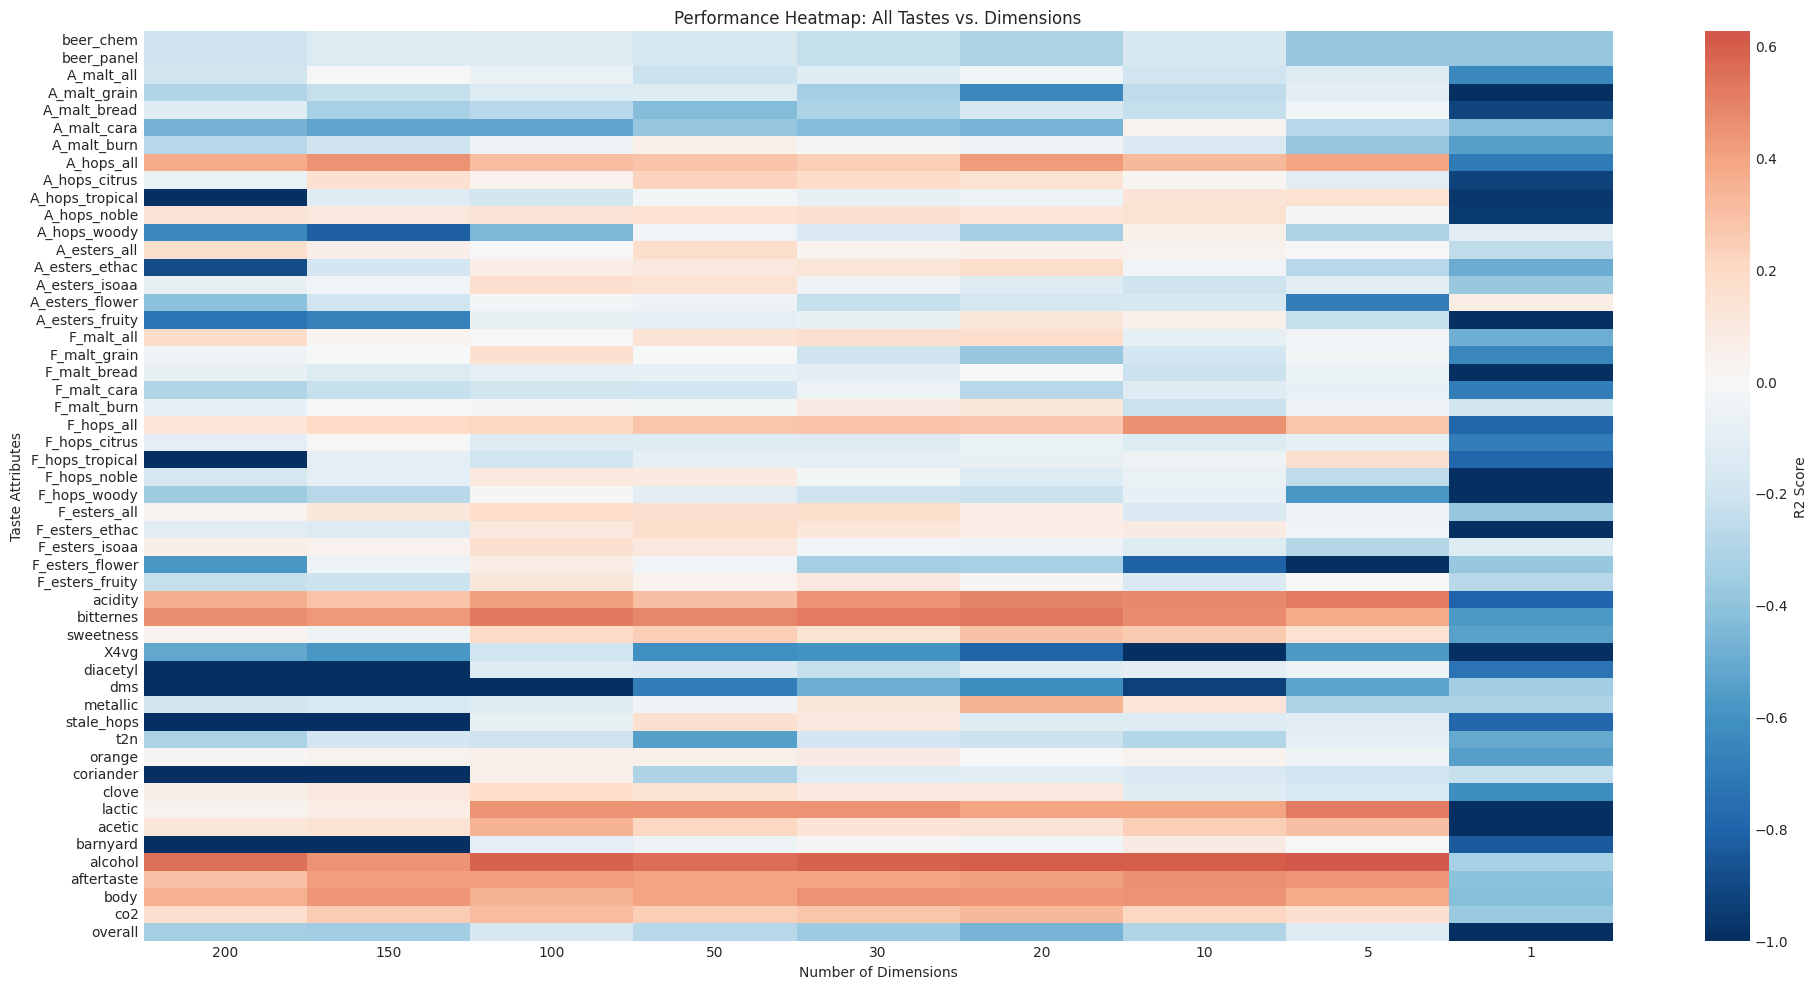

💾 결과 CSV 저장됨: /home/a202192020/맥주데이터실험/ver4/output/pca_individual_taste_results.csv

🏆 [Top 5 예측 가능한 맛]
alcohol       0.624979
bitternes     0.528933
lactic        0.517815
acidity       0.516081
F_hops_all    0.459661
dtype: object


In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from tqdm import tqdm

# =========================================================
# 📂 1. 데이터 로드 및 저장소 설정
# =========================================================
DATA_DIR = r"/home/a202192020/맥주데이터실험/ver4/output"
MODEL_DIR = os.path.join(DATA_DIR, "models")  # 모델 저장할 하위 폴더

# 폴더가 없으면 생성
os.makedirs(MODEL_DIR, exist_ok=True)

print("📂 저장된 PCA 데이터 로딩 중...")
# X 데이터 (Numpy 변환)
X_train_pca_full = pd.read_csv(os.path.join(DATA_DIR, "X_train_pca_200dim.csv")).values
X_test_pca_full = pd.read_csv(os.path.join(DATA_DIR, "X_test_pca_200dim.csv")).values

# Y 데이터 (인덱스 포함)
Y_train = pd.read_csv(os.path.join(DATA_DIR, "Y_train_stratified.csv"), index_col=0)
Y_test = pd.read_csv(os.path.join(DATA_DIR, "Y_test_stratified.csv"), index_col=0)

print(f"✅ 데이터 로드 완료! (X: {X_train_pca_full.shape})")
print(f"📂 모델 저장 경로 설정됨: {MODEL_DIR}")


# =========================================================
# ⚙️ 2. 실험 설정
# =========================================================
max_dim = X_train_pca_full.shape[1]
n_components_list = [200, 150, 100, 50, 30, 20, 10, 5, 1]
n_components_list = [n for n in n_components_list if n <= max_dim]
if max_dim not in n_components_list:
    n_components_list.insert(0, max_dim)

print(f"🚀 [실험 시작] 총 {len(Y_train.columns)}개 맛 속성 분석 및 모델 저장")
print(f"   - 실험 차원: {n_components_list}")

# 결과를 저장할 데이터프레임
result_matrix = pd.DataFrame(index=n_components_list, columns=Y_train.columns)

# 모델 객체 (매번 초기화하지 않고 fit으로 덮어쓰기 사용 -> 속도 최적화)
model = XGBRegressor(n_estimators=100, n_jobs=-1, random_state=42)


# =========================================================
# 🔄 3. 이중 반복문 (학습 -> 저장 -> 평가)
# =========================================================
for col in tqdm(Y_train.columns, desc="Training & Saving"):
    
    # 1. 타겟 데이터 준비
    y_train_col = Y_train[col]
    y_test_col = Y_test[col]
    
    # 파일명 안전하게 만들기 (슬래시나 공백을 언더바로 교체)
    safe_col_name = col.replace("/", "_").replace(" ", "_")
    
    for n in n_components_list:
        # 2. 데이터 슬라이싱
        X_train_slice = X_train_pca_full[:, :n]
        X_test_slice = X_test_pca_full[:, :n]
        
        # 3. 모델 학습
        model.fit(X_train_slice, y_train_col)
        
        # ---------------------------------------------------------
        # 💾 [수정된 부분] 학습된 모델 즉시 파일로 저장
        # ---------------------------------------------------------
        model_filename = f"model_{safe_col_name}_{n}dim.json"
        save_path = os.path.join(MODEL_DIR, model_filename)
        model.save_model(save_path)
        # ---------------------------------------------------------
        
        # 4. 평가 및 기록
        y_pred = model.predict(X_test_slice)
        score = r2_score(y_test_col, y_pred)
        result_matrix.at[n, col] = score

print("\n✅ 모든 모델 저장 및 실험 완료!")
print(f"   - 총 저장된 모델 수: {len(Y_train.columns) * len(n_components_list)}개")


# =========================================================
# 📊 4. 결과 시각화 및 결과표 저장
# =========================================================

# (1) 히트맵 저장
plt.figure(figsize=(20, 10))
sns.heatmap(result_matrix.T.astype(float).clip(lower=-1), 
            annot=False, cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'R2 Score'})
plt.title('Performance Heatmap: All Tastes vs. Dimensions')
plt.xlabel('Number of Dimensions')
plt.ylabel('Taste Attributes')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "heatmap_performance.png"), dpi=300)
plt.show()

# (2) 결과 CSV 저장
csv_path = os.path.join(DATA_DIR, "pca_individual_taste_results.csv")
result_matrix.to_csv(csv_path)
print(f"💾 결과 CSV 저장됨: {csv_path}")

# (3) Top 5 확인
max_scores = result_matrix.max(axis=0).sort_values(ascending=False)
print("\n🏆 [Top 5 예측 가능한 맛]")
print(max_scores.head(5))

# 실험 코드 분석 보고서: 중요도 기반 주성분 재정렬(Re-ordering) 및 성능 평가

## 1. 코드의 의도 (Intention)
기존 PCA는 데이터의 **분산(정보량)**이 큰 순서대로 축(PC1, PC2...)을 정렬합니다. 하지만 "분산이 크다고 해서 반드시 맛($Y$)을 잘 예측하는 것은 아니다"라는 가설을 검증하기 위해 작성된 코드입니다.

이 코드는 각 맛 속성별로 **"실제로 예측에 도움이 되는 주성분"**을 먼저 선별(Screening)하고, 그 순서대로 데이터를 재배열(Re-ordering)하여 모델에 투입합니다. 이를 통해 **더 적은 차원으로도 기존보다 높은 예측 성능**을 달성하는 것이 주된 목적입니다.

---

## 2. 실험 설계

이 실험은 **'탐색(Screening) $\rightarrow$ 재정렬(Sorting) $\rightarrow$ 검증(Validation)'**의 3단계 프로세스를 각 맛 속성마다 반복 수행합니다.

### **[Step 1] 전수 조사 및 기여도 산출 (Screening)**
* 각 맛($Y$)에 대해, 먼저 **전체 차원(200차원)**을 모두 투입하여 XGBoost 모델을 학습시킵니다.
* 학습된 모델로부터 각 차원(PC)이 예측에 얼마나 기여했는지 **Feature Importance(중요도 점수)**를 추출합니다.

### **[Step 2] 주성분 재정렬 (Re-ordering)**
* 기존의 PC1, PC2... 순서(분산 순)를 무시하고, **중요도 점수가 높은 순서대로** 주성분 인덱스를 다시 줄 세웁니다.
* 예: 만약 PC7이 가장 중요했다면, 데이터의 첫 번째 컬럼을 PC1 대신 PC7로 교체합니다.

### **[Step 3] 최적화된 차원 축소 실험 (Validation)**
* 중요도 순으로 정렬된 데이터(`X_sorted`)에서 앞에서부터 $N$개를 잘라냅니다(Slicing).
* 이 **'알짜배기 데이터'**로 다시 모델을 학습시키고 테스트 셋으로 평가($R^2$)합니다.
* 기대 결과: 불필요한 노이즈가 뒤로 밀려났으므로, 매우 적은 차원(Top 5~10)에서도 성능이 급격히 상승해야 합니다.

---

## 3. 코드-설계 매칭 (Code Mapping)

위 실험 설계가 실제 코드에 어떻게 구현되어 있는지 매칭한 내역입니다.

| 설계 단계 | 핵심 로직 설명 | 코드 매칭 (Line Reference) |
| :--- | :--- | :--- |
| **반복 수행** | 52개 맛 속성별로 별도 최적화 수행 | `for col in tqdm(Y_train.columns, ...):` |
| **Step 1. 탐색** | 중요도 파악을 위한 전체 차원 선행 학습 | `model.fit(X_train_pca_full, y_train_col)` (첫 번째 fit) |
| **중요도 추출** | 모델이 판단한 기여도 점수 획득 | `importances = model.feature_importances_` |
| **Step 2. 재정렬** | 중요도 내림차순으로 인덱스 정렬 및 데이터 변환 | `sorted_indices = np.argsort(importances)[::-1]` <br> `X_train_sorted = X_train_pca_full[:, sorted_indices]` |
| **Step 3. 검증** | 재정렬된 데이터로 차원별 재학습 및 평가 | `X_train_slice = X_train_sorted[:, :n]` <br> `model.fit(X_train_slice, y_train_col)` (두 번째 fit) |
| **결과 저장** | 성능 지표 기록 (CSV 및 Heatmap) | `result_matrix_reordered.at[n, col] = score` <br> `result_matrix_reordered.to_csv(...)` |

---

## 4. 요약
이 실험은 **Supervised Feature Selection(지도 학습 기반 특징 선택)** 기법을 PCA 차원 축소에 결합한 것입니다. 비지도 학습(PCA)의 한계인 "타겟 변수($Y$) 고려 부재"를 극복하고, **각 맛에 특화된 최적의 성분 조합**을 찾아내는 고도화된 접근 방식입니다.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from tqdm import tqdm

# =========================================================
# ⚙️ 1. 저장 경로 설정 (Ver 4)
# =========================================================
# 요청하신 경로로 설정
OUTPUT_DIR = r"/home/a202192020/맥주데이터실험/ver4/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"📂 결과 저장 경로 설정 완료: {OUTPUT_DIR}")

# =========================================================
# ⚙️ 2. 실험 설정
# =========================================================
# (이전 단계의 데이터 X_train_pca_full, Y_train 등이 메모리에 있어야 합니다)

# 실험할 차원 리스트
# (데이터가 200개 이하라면 max_dim 조절 필요)
max_dim = X_train_pca_full.shape[1]
n_components_list = [200, 150, 100, 50, 30, 20, 10, 5, 1]
n_components_list = [n for n in n_components_list if n <= max_dim]
if max_dim not in n_components_list:
    n_components_list.insert(0, max_dim)

# 결과를 저장할 DataFrame 생성 (행: 차원, 열: 맛 이름)
result_matrix_reordered = pd.DataFrame(index=n_components_list, columns=Y_train.columns)

# 모델 정의
model = XGBRegressor(n_estimators=100, n_jobs=-1, random_state=42)

print(f"🚀 [실험 시작] 중요도 기반 재정렬(Re-ordering) 분석")
print(f"   - 대상: {len(Y_train.columns)}개 맛 속성")
print(f"   - 차원: {n_components_list}")

# =========================================================
# 🔄 3. 이중 반복문 (맛 별로 -> 중요도 정렬 -> 차원 별로)
# =========================================================
for col in tqdm(Y_train.columns, desc="Processing Tastes"):
    
    y_train_col = Y_train[col]
    y_test_col = Y_test[col]
    
    # -----------------------------------------------------
    # Step A. 중요도 파악을 위해 일단 전체(Full Dim) 학습
    # -----------------------------------------------------
    model.fit(X_train_pca_full, y_train_col)
    
    # -----------------------------------------------------
    # Step B. 중요도 순서대로 인덱스 줄 세우기 (Sorting)
    # -----------------------------------------------------
    importances = model.feature_importances_
    # 중요도가 높은 순서대로 인덱스 정렬 (내림차순)
    sorted_indices = np.argsort(importances)[::-1]
    
    # 데이터의 컬럼 순서를 바꿈 (재정렬된 데이터 생성)
    X_train_sorted = X_train_pca_full[:, sorted_indices]
    X_test_sorted = X_test_pca_full[:, sorted_indices] 
    
    # -----------------------------------------------------
    # Step C. 재정렬된 데이터로 슬라이싱 실험 (Slicing)
    # -----------------------------------------------------
    for n in n_components_list:
        # 앞에서부터 n개 자르기 (가장 중요한 n개만 남음)
        X_train_slice = X_train_sorted[:, :n]
        X_test_slice = X_test_sorted[:, :n]
        
        # 다시 학습 (최적화된 입력)
        model.fit(X_train_slice, y_train_col)
        
        # 평가
        y_pred = model.predict(X_test_slice)
        score = r2_score(y_test_col, y_pred)
        
        # 결과 기록
        result_matrix_reordered.at[n, col] = score

print("\n✅ 모든 실험 완료!")

# =========================================================
# 💾 4. 결과 저장 (CSV & Plot)
# =========================================================

# (1) 결과 CSV 저장
csv_filename = "pca_reordered_importance_results.csv"
csv_path = os.path.join(OUTPUT_DIR, csv_filename)
result_matrix_reordered.to_csv(csv_path)
print(f"💾 CSV 저장 완료: {csv_path}")

# (2) 히트맵 저장
plt.figure(figsize=(20, 10))
sns.heatmap(result_matrix_reordered.T.astype(float).clip(lower=-1), 
            annot=False, cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'R2 Score (Re-ordered)'})
plt.title('Performance Heatmap (Sorted by Importance)')
plt.xlabel('Number of Dimensions')
plt.ylabel('Taste Attributes')
plt.tight_layout()

heatmap_path = os.path.join(OUTPUT_DIR, "heatmap_reordered.png")
plt.savefig(heatmap_path, dpi=300)
plt.close() # 메모리 해제
print(f"💾 히트맵 이미지 저장 완료: {heatmap_path}")

# (3) Top 5 요약 출력
max_scores = result_matrix_reordered.max(axis=0).sort_values(ascending=False)
print("\n🏆 [재정렬 실험 Top 5 예측 성능]")
print(max_scores.head(5))